In [4]:
import numpy as np
import pandas as pd
import statistics

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, pointbiserialr
from scipy.stats import f_oneway, kruskal

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_validate, train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score

plt.style.use('default')
sns.set_palette("husl")
SEED = 43
np.random.seed(SEED)


In [5]:
data = pd.read_csv("../data/data.csv", index_col=0)
print(data)

      country time_of_day                                    coords  \
8459       SE         day    (55.6042088835034, 13.028574055029615)   
63960      DE         day    (50.93688916245651, 6.908079399321095)   
71801      IT         day   (41.98701399467725, 12.496537666755511)   
85589      IT       night   (41.79485347012337, 12.522879577369833)   
90649      DE         day    (49.182152679755596, 9.41473726958959)   
...       ...         ...                                       ...   
74962      PL         day  (54.378438934468846, 18.605984330555252)   
90673      PL         day   (50.25321741970741, 19.823732415289637)   
24373      DE         day   (50.931398765690794, 6.953686151822246)   
41597      SE         day   (55.60814946072964, 13.003458001026049)   
40353      IT       night  (41.918667186625505, 12.383544858842713)   

            road_type road_condition            weather  \
8459             city         normal             cloudy   
63960  arterial-urban        

In [6]:
all_columns = data.columns    

print(f"Number of rows: {data.shape[0]}")
print(f"Columns: {all_columns}")
print(f"Number of columns: {len(all_columns)}")

Number of rows: 10022
Columns: Index(['country', 'time_of_day', 'coords', 'road_type', 'road_condition',
       'weather', 'solar_angle_elevation', 'month', 'hour', 'temperature_2m',
       'relative_humidity_2m', 'precipitation', 'rain', 'snowfall',
       'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid',
       'sunshine_duration', 'wind_speed_10m', 'weather_code', 'conf', 'iou'],
      dtype='object')
Number of columns: 22


In [7]:
numeric_columns = ['coords', 'solar_angle_elevation', 'month', 'hour', 'temperature_2m',
       'relative_humidity_2m', 'precipitation', 'rain', 'snowfall',
       'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid',
       'sunshine_duration', 'wind_speed_10m', 'conf', 'iou']
categorical_columns = ['time_of_day', 'country', 'road_type', 'road_condition',
       'weather', 'weather_code']

assert len(all_columns) == (len(categorical_columns) + len(numeric_columns)), "Columns not match"


# EDA

## Categorical Variables

In [8]:
print(f"Number of categorical features: {len(categorical_columns)}")
for col in categorical_columns:
    print("-" * 10)
    print(f"Column: {col}")
    print(f"Unique values: {data[col].nunique()}")
    print(f"Most common: {data[col].mode().iloc[0] if not data[col].mode().empty else 'N/A'}")
    print(f"Missing values: {data[col].isnull().sum()}")

Number of categorical features: 6
----------
Column: time_of_day
Unique values: 3
Most common: day
Missing values: 0
----------
Column: country
Unique values: 9
Most common: DE
Missing values: 0
----------
Column: road_type
Unique values: 5
Most common: city
Missing values: 0
----------
Column: road_condition
Unique values: 3
Most common: normal
Missing values: 0
----------
Column: weather
Unique values: 9
Most common: partly-cloudy-day
Missing values: 0
----------
Column: weather_code
Unique values: 1
Most common: 0.0
Missing values: 0


Distribution

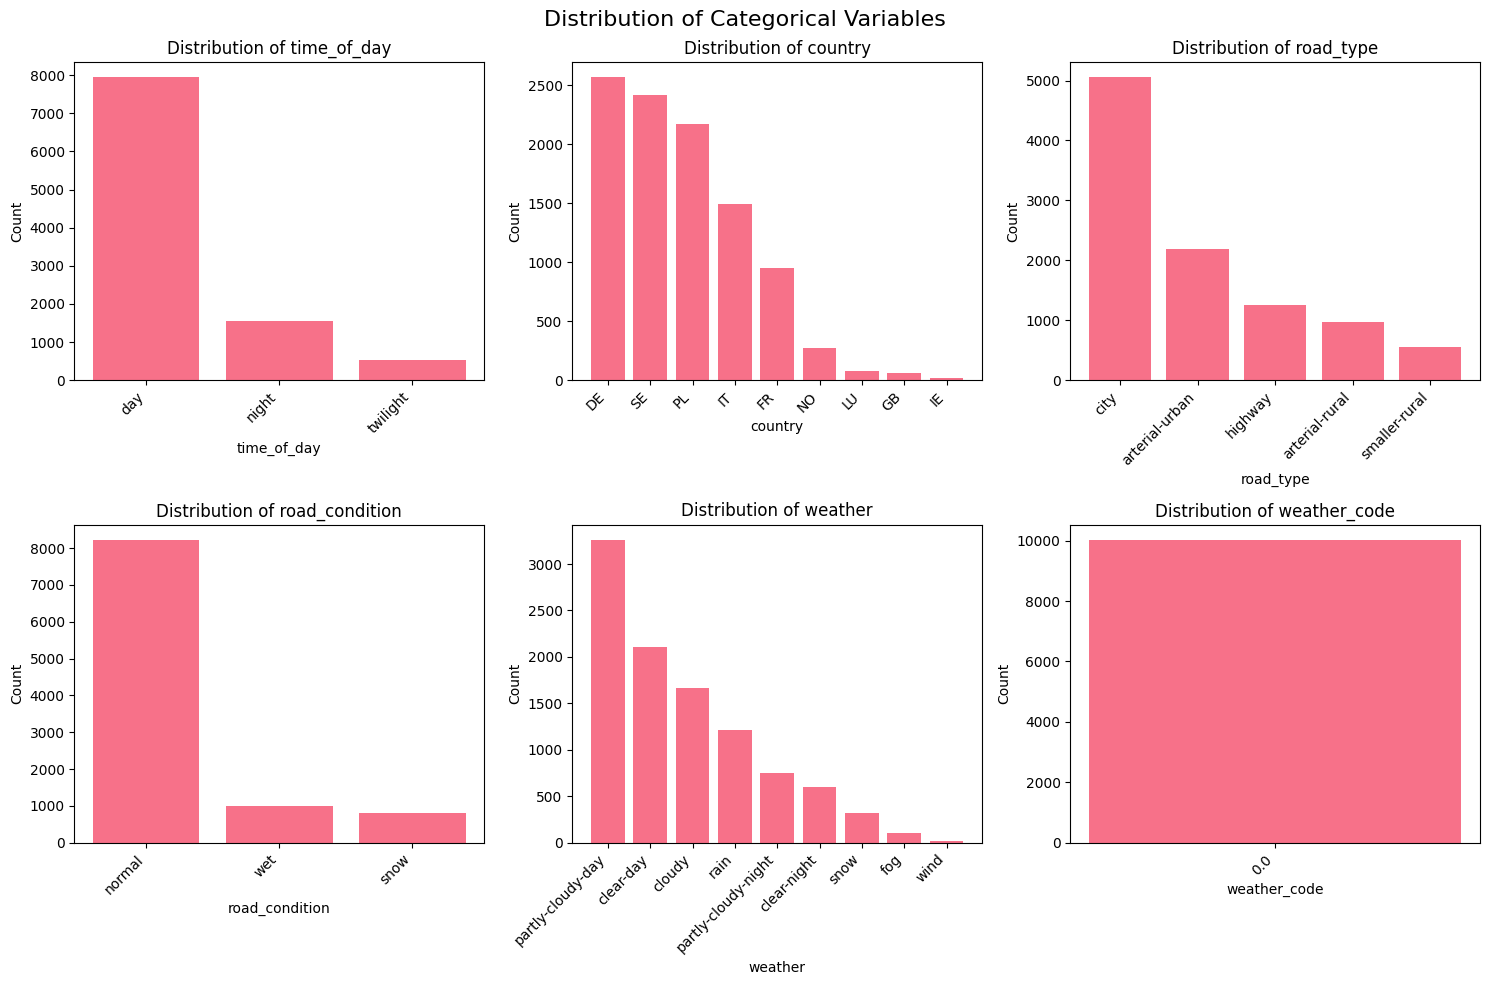

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Categorical Variables', fontsize=16)

axes = axes.flatten()

for i, column in enumerate(categorical_columns):
    value_counts = data[column].value_counts()
    axes[i].bar(range(len(value_counts)), value_counts.values)
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')
    
    axes[i].set_xticks(range(len(value_counts)))
    axes[i].set_xticklabels(value_counts.index, rotation=45, ha='right')


plt.tight_layout()
plt.show()

Correlation - Using Pearson and labels encoded

In [10]:

encoded_data = data[categorical_columns].copy()
label_encoders = {}
for column in categorical_columns:
    le = LabelEncoder()
    encoded_data[column] = encoded_data[column].fillna('Unknown')
    encoded_data[column] = le.fit_transform(encoded_data[column])
    label_encoders[column] = le

pearson_corr = encoded_data.corr()
print(pearson_corr.round(3))

                time_of_day  country  road_type  road_condition  weather  \
time_of_day           1.000   -0.179      0.078           0.014    0.168   
country              -0.179    1.000     -0.030           0.161    0.001   
road_type             0.078   -0.030      1.000          -0.073   -0.076   
road_condition        0.014    0.161     -0.073           1.000    0.335   
weather               0.168    0.001     -0.076           0.335    1.000   
weather_code            NaN      NaN        NaN             NaN      NaN   

                weather_code  
time_of_day              NaN  
country                  NaN  
road_type                NaN  
road_condition           NaN  
weather                  NaN  
weather_code             NaN  


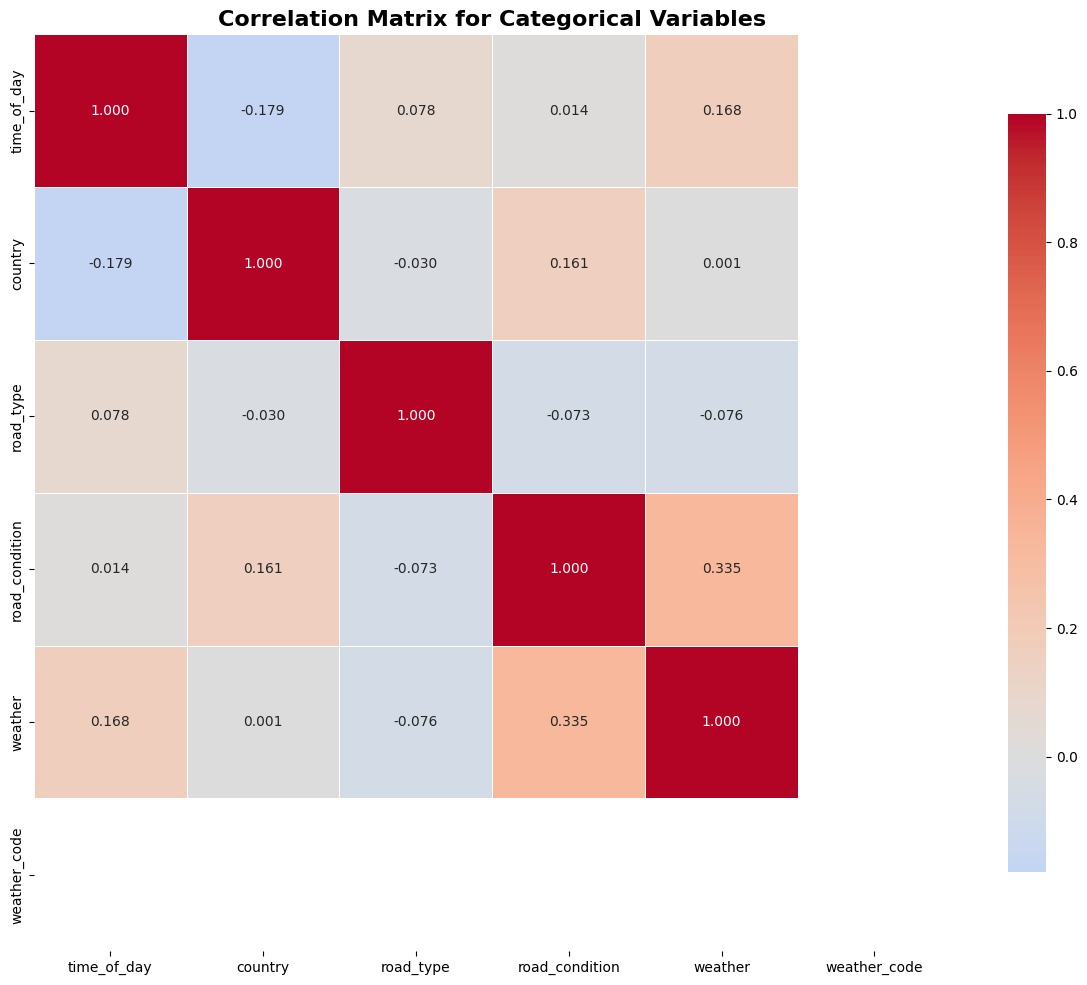

In [11]:
plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0,square=True, linewidths=0.5, fmt='.3f', cbar_kws={"shrink": .8})
plt.title("Correlation Matrix for Categorical Variables", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Numerical Variables 

In [12]:
print(f"Number of numerical features: {len(numeric_columns)}")
for col in numeric_columns:
    if col == 'coords':
        continue
    clean_data = data[column].dropna()
    print(f"\n{column.upper()}:")
    print(f"  Count: {len(clean_data)}")
    print(f"  Missing values: {data[column].isnull().sum()}")
    print(f"  Mean: {clean_data.mean():.3f}")
    print(f"  Median: {clean_data.median():.3f}")
    print(f"  Std: {clean_data.std():.3f}")
    print(f"  Min: {clean_data.min():.3f}")
    print(f"  Max: {clean_data.max():.3f}")
    print(f"  Range: {clean_data.max() - clean_data.min():.3f}")
    

Number of numerical features: 16

WEATHER_CODE:
  Count: 10022
  Missing values: 0
  Mean: 0.000
  Median: 0.000
  Std: 0.000
  Min: 0.000
  Max: 0.000
  Range: 0.000

WEATHER_CODE:
  Count: 10022
  Missing values: 0
  Mean: 0.000
  Median: 0.000
  Std: 0.000
  Min: 0.000
  Max: 0.000
  Range: 0.000

WEATHER_CODE:
  Count: 10022
  Missing values: 0
  Mean: 0.000
  Median: 0.000
  Std: 0.000
  Min: 0.000
  Max: 0.000
  Range: 0.000

WEATHER_CODE:
  Count: 10022
  Missing values: 0
  Mean: 0.000
  Median: 0.000
  Std: 0.000
  Min: 0.000
  Max: 0.000
  Range: 0.000

WEATHER_CODE:
  Count: 10022
  Missing values: 0
  Mean: 0.000
  Median: 0.000
  Std: 0.000
  Min: 0.000
  Max: 0.000
  Range: 0.000

WEATHER_CODE:
  Count: 10022
  Missing values: 0
  Mean: 0.000
  Median: 0.000
  Std: 0.000
  Min: 0.000
  Max: 0.000
  Range: 0.000

WEATHER_CODE:
  Count: 10022
  Missing values: 0
  Mean: 0.000
  Median: 0.000
  Std: 0.000
  Min: 0.000
  Max: 0.000
  Range: 0.000

WEATHER_CODE:
  Count: 10022

Distribution

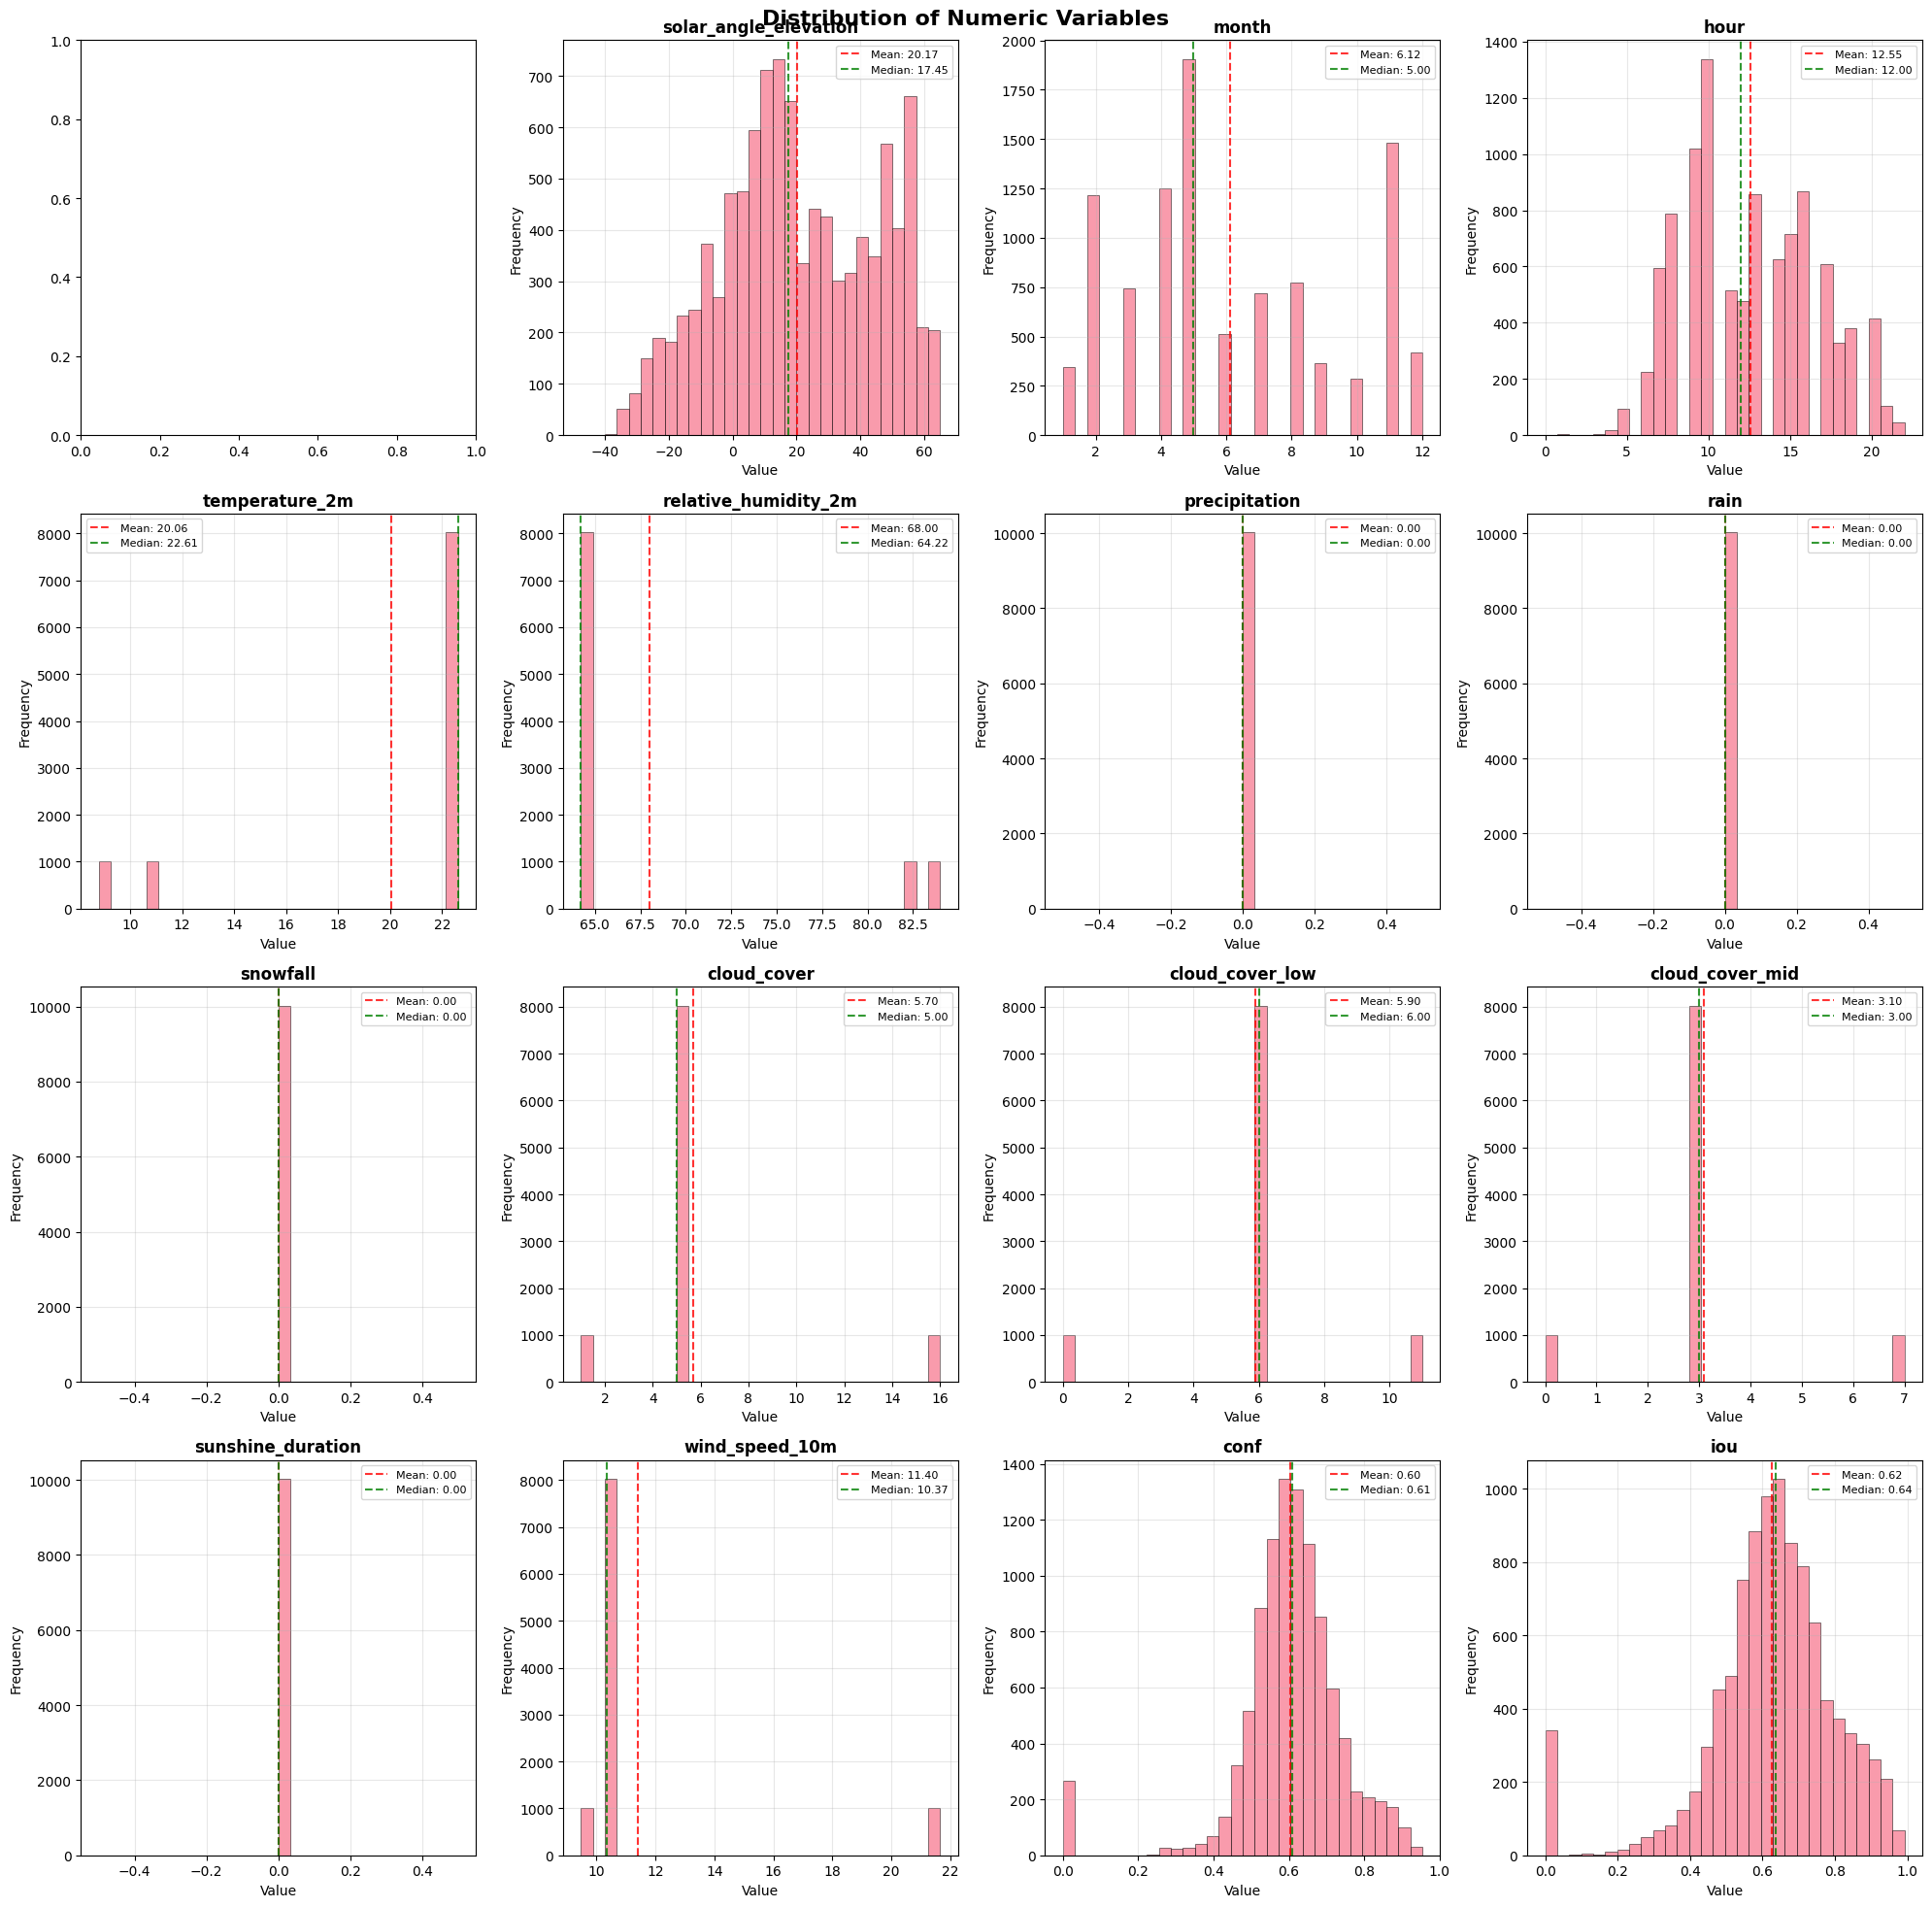

In [13]:
n_cols = 4
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('Distribution of Numeric Variables', fontsize=16, fontweight='bold')
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

for i, column in enumerate(numeric_columns):
    if column == 'coords':
        continue
    clean_data = data[column].dropna()
    
    axes[i].hist(clean_data, bins=30, alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'{column}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)
    
    mean_val = clean_data.mean()
    median_val = clean_data.median()
    axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', alpha=0.8, label=f'Median: {median_val:.2f}')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

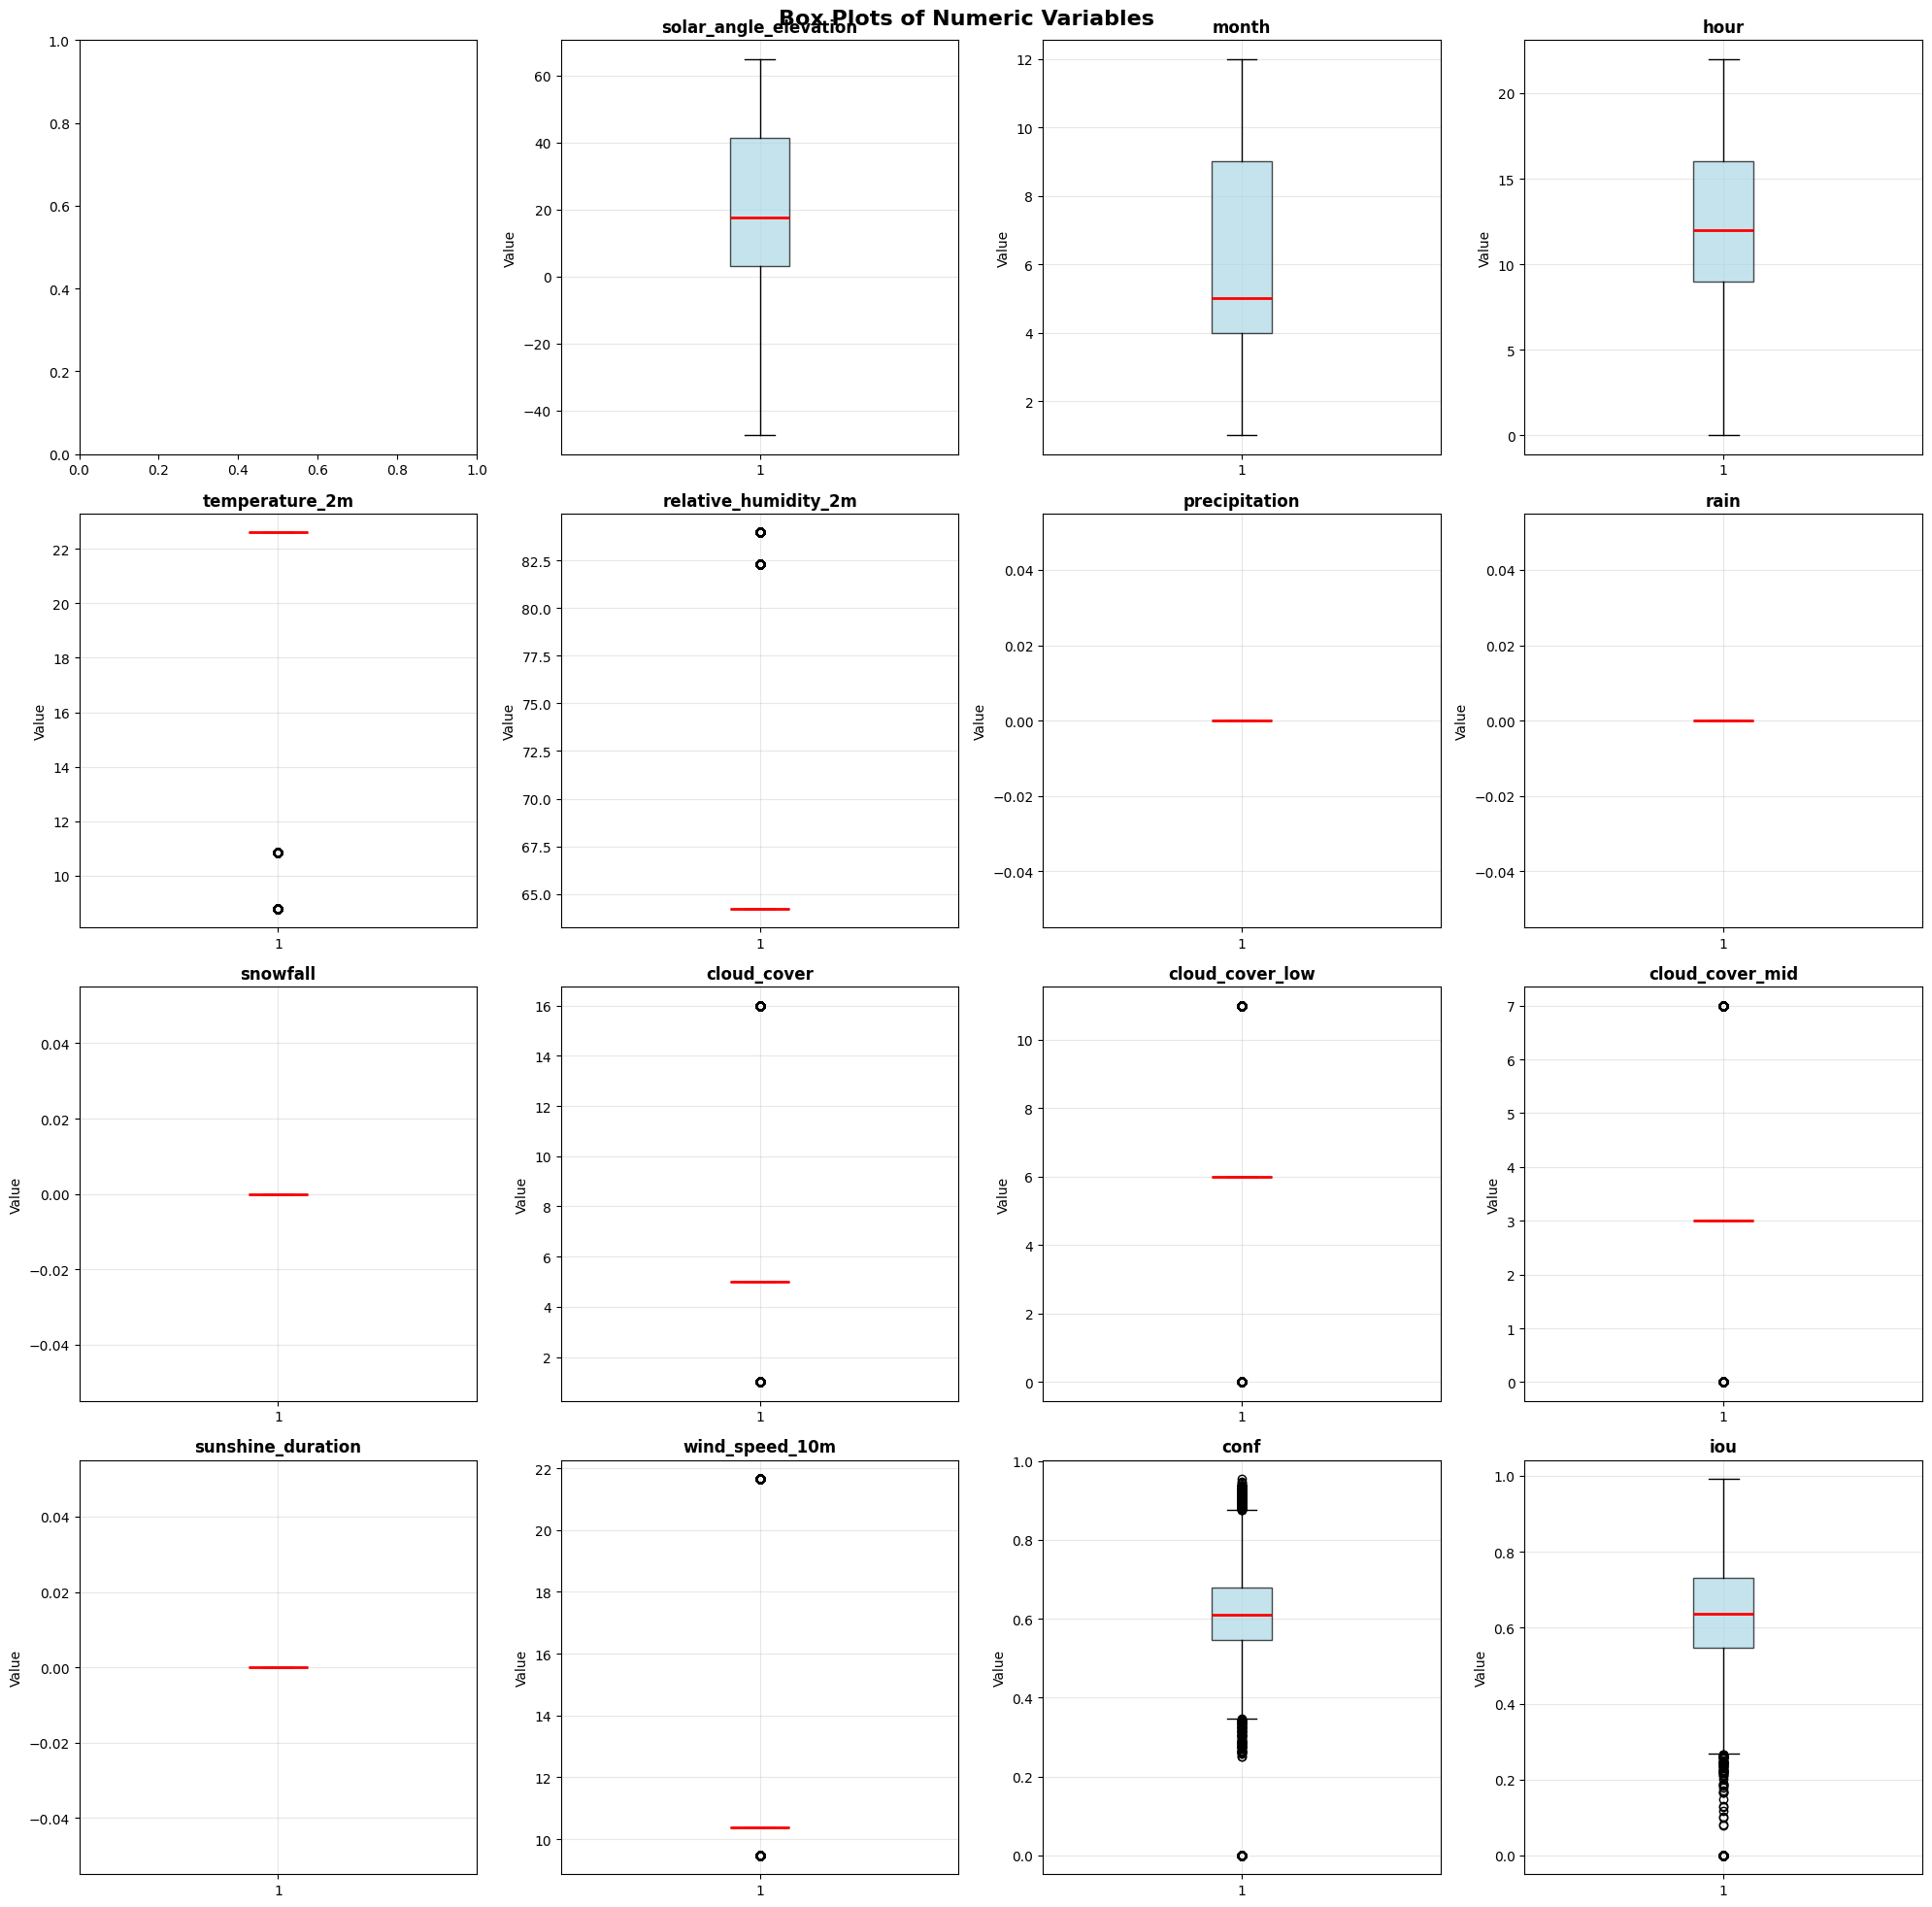

In [14]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('Box Plots of Numeric Variables', fontsize=16, fontweight='bold')

# Flatten axes array for easier indexing
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

for i, column in enumerate(numeric_columns):
    if column == 'coords':
        continue
    clean_data = data[column].dropna()
    
    # Create box plot
    axes[i].boxplot(clean_data, patch_artist=True, 
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{column}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

# Hide any unused subplots
for i in range(len(numeric_columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


Correlation

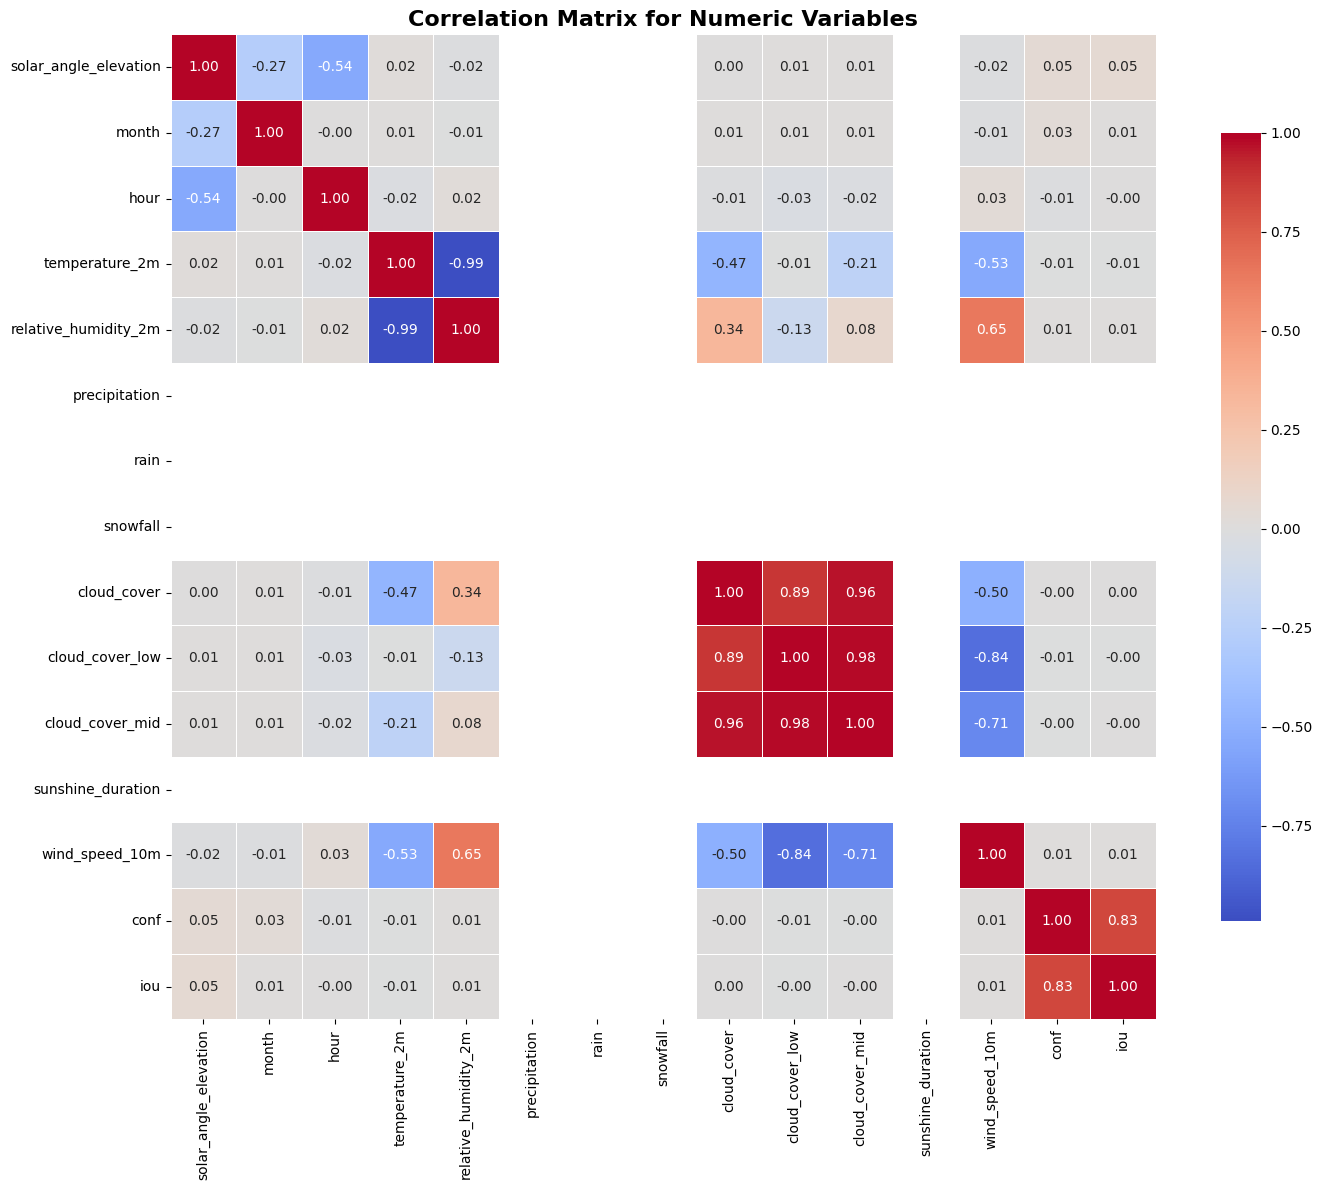

In [15]:
numeric_data = data[numeric_columns].select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr('pearson')

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,square=True, linewidths=0.5, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix for Numeric Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Bivariate Correlation

Bivariate correlations between all these features and against the pass/fail result (success rate) for an instance

### Categorical Var

Use Etta-square for correlation between varaibles and IoU.
It measures the proportion of variance associated with each main effect and interaction effect in an ANOVA model.

In [16]:
categorical_correlations = []

for col in categorical_columns:
    categories = data[col].unique()
    groups = [data[data[col] == cat]['iou'].values for cat in categories]
    groups = [group for group in groups if len(group) > 0]  
    
    if len(groups) >= 2:
        overall_mean = data['iou'].mean()
        ssb = sum(len(group) * (np.mean(group) - overall_mean)**2 for group in groups)
        sst = sum((data['iou'] - overall_mean)**2)
        eta_squared = ssb / sst if sst != 0 else 0
        categorical_correlations.append({'col': col,'Eta_Squared': eta_squared,})

categorical_corr_df = pd.DataFrame(categorical_correlations)
categorical_corr_df = categorical_corr_df.sort_values('Eta_Squared', ascending=False)

print(categorical_corr_df.round(4))

              col  Eta_Squared
1         country       0.0135
2       road_type       0.0105
3  road_condition       0.0084
4         weather       0.0062
0     time_of_day       0.0017


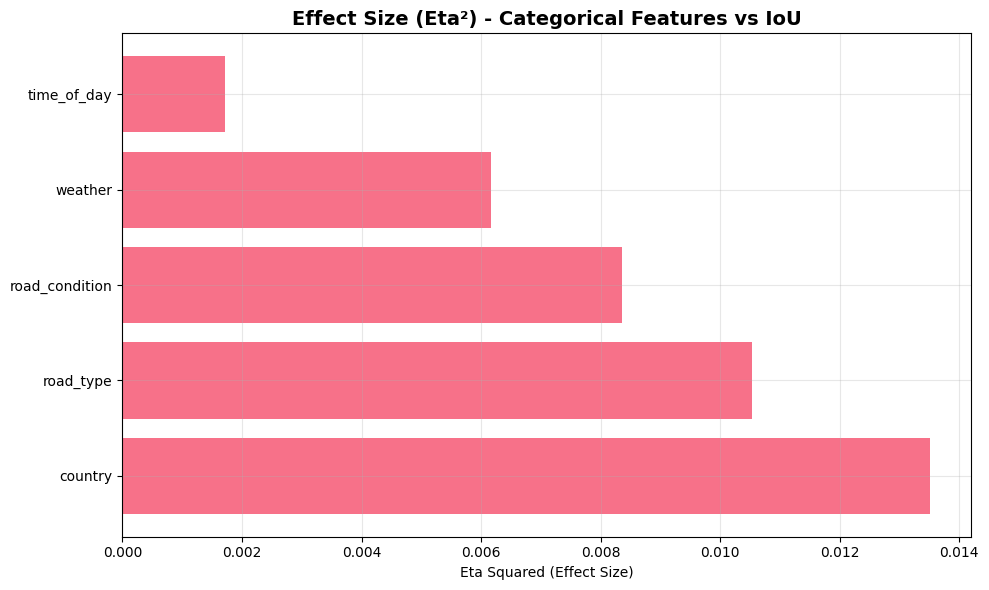

In [17]:
plt.figure(figsize=(10, 6))
plt.barh(categorical_corr_df['col'], categorical_corr_df['Eta_Squared'])
plt.title('Effect Size (Eta²) - Categorical Features vs IoU', fontsize=14, fontweight='bold')
plt.xlabel('Eta Squared (Effect Size)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Numerical Var

Plots relationship between variables and IoU using both Pearson and Spearman correlation. 

In [18]:
numeric_correlations = []

for col in numeric_columns:
    if col == "coords":
        continue
    pearson_corr, pearson_p = pearsonr(data[col], data['iou'])
    spearman_corr, spearman_p = spearmanr(data[col], data['iou'])
    
    numeric_correlations.append({
        'col': col,
        'Pearson_Corr': pearson_corr,
        'Spearman_Corr': spearman_corr,
    })

numeric_corr_df = pd.DataFrame(numeric_correlations)
numeric_corr_df = numeric_corr_df.sort_values('Pearson_Corr', key=abs, ascending=False)
print(numeric_corr_df.round(4))

                      col  Pearson_Corr  Spearman_Corr
14                    iou        1.0000         1.0000
13                   conf        0.8308         0.7514
0   solar_angle_elevation        0.0524         0.0096
1                   month        0.0126        -0.0403
4    relative_humidity_2m        0.0106         0.0109
3          temperature_2m       -0.0102        -0.0092
12         wind_speed_10m        0.0088         0.0079
9         cloud_cover_low       -0.0039        -0.0079
2                    hour       -0.0026         0.0168
10        cloud_cover_mid       -0.0017        -0.0079
8             cloud_cover        0.0013        -0.0079
5           precipitation           NaN            NaN
6                    rain           NaN            NaN
7                snowfall           NaN            NaN
11      sunshine_duration           NaN            NaN


/tmp/ipykernel_1661787/3549118436.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, pearson_p = pearsonr(data[col], data['iou'])
/tmp/ipykernel_1661787/3549118436.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, spearman_p = spearmanr(data[col], data['iou'])


<Figure size 640x480 with 0 Axes>

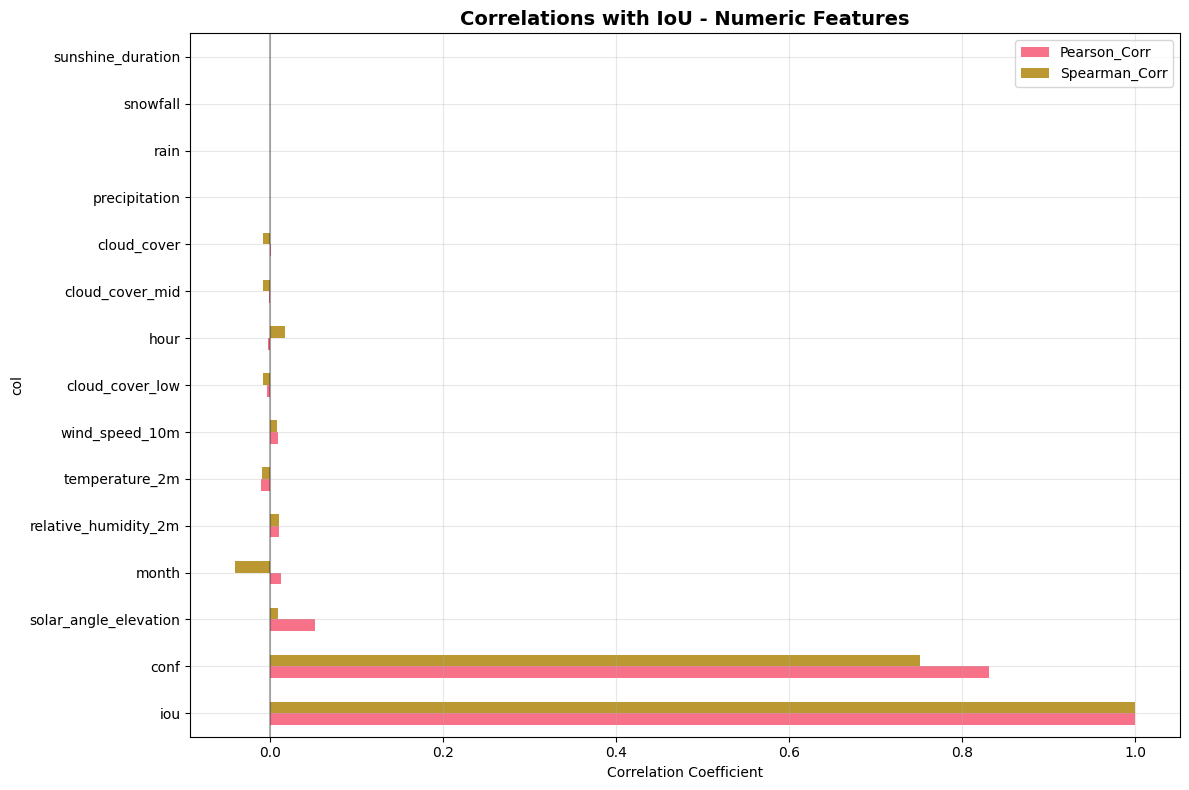

In [19]:
plt.figure()
correlations_plot = numeric_corr_df.set_index('col')[['Pearson_Corr', 'Spearman_Corr']]
correlations_plot.plot(kind='barh', figsize=(12, 8))
plt.title('Correlations with IoU - Numeric Features', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Characteristic Curves

Success rate (IoU) vs Relevant or Irrelevant feature. Try this for both. Are of curve = capability. Also Black dashed line is added to show the linear regression for the black points (pass/fail). 

The conformances (Spearman correlations against monotonic sequence) are 0.80, 0.60, 1.00 and −0.50, respectively. Dont completly understand this.

## Agent Characteristic Grids

Placing each feature as a dimension and the success rate (or other performance metric) represented in colours (or shade of grey).

# Assessor Tests

Baseline, confidence vs IoU

In [20]:
baseline = r2_score(data["iou"], data["conf"])
print(f"R2 score of baseline {baseline}")

R2 score of baseline 0.6767337794229915


Split data into train 60% and validation 40%

In [21]:
#X_train, X_test, y_train, y_test = train_test_split(data, test_size=0.4, train_size=0.6, stratify=data["iou"])
X_train, X_test = train_test_split(data, test_size=0.4, train_size=0.6)
y_train = X_train["iou"]
del X_train["coords"]
del X_train["iou"]

y_test = X_test["iou"]
del X_test["coords"]
del X_test["iou"]

print("X:", len(X_train), len(X_test))
print("y:", len(y_train), len(y_test))
print(X_train.columns)

X: 6013 4009
y: 6013 4009
Index(['country', 'time_of_day', 'road_type', 'road_condition', 'weather',
       'solar_angle_elevation', 'month', 'hour', 'temperature_2m',
       'relative_humidity_2m', 'precipitation', 'rain', 'snowfall',
       'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid',
       'sunshine_duration', 'wind_speed_10m', 'weather_code', 'conf'],
      dtype='object')


In [22]:
train_numeric_columns = ['solar_angle_elevation', 'month', 'hour', 'temperature_2m',
       'relative_humidity_2m', 'precipitation', 'rain', 'snowfall',
       'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid',
       'sunshine_duration', 'wind_speed_10m', 'conf']
train_categorical_columns = ['time_of_day', 'country', 'road_type', 'road_condition',
       'weather', 'weather_code']

Train models with cv and then test.

Linear Regression

In [23]:
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), train_numeric_columns),('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), train_categorical_columns)],remainder='passthrough')

linear_reg = Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())])
cv_lr = cross_validate(linear_reg, X_train, y_train, cv=10, scoring=("r2", "neg_mean_absolute_error", "neg_mean_squared_error"), return_train_score=True)
print(f"Mean CV train r2 score {statistics.mean(cv_lr["train_r2"])}")
print(f"Mean CV test r2 score {statistics.mean(cv_lr["test_r2"])}")
print(f"Mean CV train MAE score {statistics.mean(cv_lr["train_neg_mean_absolute_error"])}")
print(f"Mean CV test MAE score {statistics.mean(cv_lr["test_neg_mean_absolute_error"])}")
print(f"Mean CV train MSE score {statistics.mean(cv_lr["train_neg_mean_squared_error"])}")
print(f"Mean CV test MSE score {statistics.mean(cv_lr["test_neg_mean_squared_error"])}")

Mean CV train r2 score 0.6879640322481578
Mean CV test r2 score 0.6812014923358256
Mean CV train MAE score -0.0715200344146549
Mean CV test MAE score -0.07201669218243284
Mean CV train MSE score -0.010415722190118316
Mean CV test MSE score -0.010574333491473924


In [24]:
linear_reg.fit(X_train, y_train)

y_pred = linear_reg.predict(X_test)
lr_test_r2 = r2_score(y_test, y_pred)
print(f"R2 test score {lr_test_r2}")

R2 test score 0.6957332158530523


Decision Trees

In [25]:
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), train_numeric_columns),('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), train_categorical_columns)],remainder='passthrough')

decision_tree = Pipeline([("preprocessor", preprocessor), ("model", DecisionTreeRegressor())])
cv_dt = cross_validate(decision_tree, X_train, y_train, cv=10, scoring=("r2", "neg_mean_absolute_error", "neg_mean_squared_error"), return_train_score=True)
print(f"Mean CV train r2 score {statistics.mean(cv_dt["train_r2"])}")
print(f"Mean CV test r2 score {statistics.mean(cv_dt["test_r2"])}")
print(f"Mean CV train MAE score {statistics.mean(cv_dt["train_neg_mean_absolute_error"])}")
print(f"Mean CV test MAE score {statistics.mean(cv_dt["test_neg_mean_absolute_error"])}")
print(f"Mean CV train MSE score {statistics.mean(cv_dt["train_neg_mean_squared_error"])}")
print(f"Mean CV test MSE score {statistics.mean(cv_dt["test_neg_mean_squared_error"])}")

Mean CV train r2 score 1.0
Mean CV test r2 score 0.30479444468479605
Mean CV train MAE score 0.0
Mean CV test MAE score -0.10560070914241951
Mean CV train MSE score 0.0
Mean CV test MSE score -0.0230807338444881


In [26]:
decision_tree.fit(X_train, y_train)
y_pred = decision_tree.predict(X_test)
lr_test_r2 = r2_score(y_test, y_pred)
print(f"R2 test score {lr_test_r2}")

R2 test score 0.3901213446214966


Random Forest

In [27]:
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), train_numeric_columns),('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), train_categorical_columns)],remainder='passthrough')

rand_forest = Pipeline([("preprocessor", preprocessor), ("model", RandomForestRegressor())])
cv_rf = cross_validate(rand_forest, X_train, y_train, cv=10, scoring=("r2", "neg_mean_absolute_error", "neg_mean_squared_error"), return_train_score=True)
print(f"Mean CV train r2 score {statistics.mean(cv_rf["train_r2"])}")
print(f"Mean CV test r2 score {statistics.mean(cv_rf["test_r2"])}")
print(f"Mean CV train MAE score {statistics.mean(cv_rf["train_neg_mean_absolute_error"])}")
print(f"Mean CV test MAE score {statistics.mean(cv_rf["test_neg_mean_absolute_error"])}")
print(f"Mean CV train MSE score {statistics.mean(cv_rf["train_neg_mean_squared_error"])}")
print(f"Mean CV test MSE score {statistics.mean(cv_rf["test_neg_mean_squared_error"])}")

Mean CV train r2 score 0.949023017071226
Mean CV test r2 score 0.6330156387990007
Mean CV train MAE score -0.02858857110949462
Mean CV test MAE score -0.0771834679762279
Mean CV train MSE score -0.001701759934552097
Mean CV test MSE score -0.012202954687821097


In [28]:
rand_forest.fit(X_train, y_train)
y_pred = rand_forest.predict(X_test)
lr_test_r2 = r2_score(y_test, y_pred)
print(f"R2 test score {lr_test_r2}")

R2 test score 0.6603463502727048


MLP

In [29]:
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), train_numeric_columns),('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), train_categorical_columns)],remainder='passthrough')

mlp = Pipeline([("preprocessor", preprocessor), ("model", MLPRegressor())])
cv_mlp = cross_validate(mlp, X_train, y_train, cv=10, scoring=("r2", "neg_mean_absolute_error", "neg_mean_squared_error"), return_train_score=True)
print(f"Mean CV train r2 score {statistics.mean(cv_mlp["train_r2"])}")
print(f"Mean CV test r2 score {statistics.mean(cv_mlp["test_r2"])}")
print(f"Mean CV train MAE score {statistics.mean(cv_mlp["train_neg_mean_absolute_error"])}")
print(f"Mean CV test MAE score {statistics.mean(cv_mlp["test_neg_mean_absolute_error"])}")
print(f"Mean CV train MSE score {statistics.mean(cv_mlp["train_neg_mean_squared_error"])}")
print(f"Mean CV test MSE score {statistics.mean(cv_mlp["test_neg_mean_squared_error"])}")

Mean CV train r2 score 0.7005492375835284
Mean CV test r2 score 0.644603789880467
Mean CV train MAE score -0.07227605224095585
Mean CV test MAE score -0.07768709932900472
Mean CV train MSE score -0.009994091175773595
Mean CV test MSE score -0.011796304758567796


In [30]:
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)
lr_test_r2 = r2_score(y_test, y_pred)
print(f"R2 test score {lr_test_r2}")

R2 test score 0.677378195485226
